<a href="https://colab.research.google.com/github/sheicksen/CISC483-EngageTactics/blob/JiaQi-RNN-predict_YouTube_engagement/RNN_on_YouTube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformers

To load the tokenizer from the saved JSON file, you can use `tf.keras.preprocessing.text.tokenizer_from_json()`.

In [2]:
import json
from tensorflow.keras.preprocessing.text import tokenizer_from_json

# Load the tokenizer from the JSON file
with open('tokenizer.json', 'r', encoding='utf-8') as f:
    loaded_tokenizer_json = json.load(f)
    loaded_tokenizer = tokenizer_from_json(loaded_tokenizer_json)

print("Tokenizer loaded successfully.")
# You can verify it by checking its word_index
print(f"Loaded tokenizer vocabulary size: {len(loaded_tokenizer.word_index)}")

Tokenizer loaded successfully.
Loaded tokenizer vocabulary size: 66620


Now that the tokenizer is loaded, you can use it to encode text. Here's a quick example:

In [3]:
sample_text = "This is a sample sentence to tokenize."
encoded_input = loaded_tokenizer.texts_to_sequences([sample_text]) # texts_to_sequences expects a list of texts

print("Original text:", sample_text)
print("Encoded input:", encoded_input)

Original text: This is a sample sentence to tokenize.
Encoded input: [[24, 8, 6, 7692, 3648, 3, 1]]


In [4]:
## Data is stored in the cache for ease of access / disposal
yt_path = kagglehub.dataset_download("bsthere/youtube-trending-videos-stats-2026")

print("Path to YouTube dataset files:", yt_path)

100%|██████████| 38.0M/38.0M [00:00<00:00, 188MB/s]

Extracting files...


Path to YouTube dataset files: /root/.cache/kagglehub/datasets/bsthere/youtube-trending-videos-stats-2026/versions/3


In [5]:
## Import US YouTube Data
yt_df = pd.read_csv(yt_path + "/US_Trending.csv")

print(yt_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16400 entries, 0 to 16399
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       16400 non-null  object
 1   trending_date  16400 non-null  object
 2   title          16400 non-null  object
 3   channel_title  16399 non-null  object
 4   views          16400 non-null  int64 
 5   likes          16400 non-null  int64 
 6   dislikes       16400 non-null  int64 
 7   publish_time   16400 non-null  object
 8   category_id    16400 non-null  int64 
 9   tags           16400 non-null  object
 10  comments       16400 non-null  int64 
 11  channel_id     16400 non-null  object
 12  description    13580 non-null  object
dtypes: int64(5), object(8)
memory usage: 1.6+ MB
None


In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# what the model will classify based on (title & description)
X = yt_df['title'] + " [SEP] " + yt_df['description']

MAX_SEQUENCE_LENGTH = 150 # longest the text can be

# Fill NaN values with empty strings before tokenizing
X_processed = X.fillna('')
X_tokenized = loaded_tokenizer.texts_to_sequences(X_processed)

# Pad sequences to ensure uniform length
padded_X_tokenized = pad_sequences(X_tokenized, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
print("Example after tokenizing and padding:", padded_X_tokenized[0])

Example after tokenizing and padding: [   1    1   16 1008 6036    1  792  406    1 1302   15    1    1 5675
 8525 5974 5675 4172    1    1    1 8031 8525 5974 8031 4172    1    1
    1    1    2    1   54   69 1538  261 8525    1    1    3    1    1
    1 1551    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]


In [7]:
import tensorflow as tf

# Load the pretrained embedding model
pretrained_model = tf.keras.models.load_model('/content/pretrained_embedding_model.keras')

print("Pretrained embedding model loaded successfully.")
pretrained_model.summary()

Pretrained embedding model loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 13 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (32, 150, 300)         │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (32, 128)              │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,390,404 (24.38 MB)

 Trainable params: 3,195,201 (12.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,195,203 (12.19 MB)

In [24]:
# have model predict on youtube data, and then structure the results
predictions = pretrained_model.predict(padded_X_tokenized)
binary_predictions = np.round(predictions).flatten()

# add column to dataframe with results
yt_df['is_real_news'] = binary_predictions

# split up real and fake news
real_news_df = yt_df[yt_df['is_real_news'] == 1]
fake_news_df = yt_df[yt_df['is_real_news'] == 0]

 35/513 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step

KeyboardInterrupt: 

In [25]:
# stats and comparison of engagement

print("\n--- Real News Analysis (is_real_news = 1) ---")
print(f"Count: {len(real_news_df)}")
print(f"Mean Likes: {real_news_df['likes'].mean():.2f}")
print(f"Median Likes: {real_news_df['likes'].median():.2f}")
print(f"Mean Views: {real_news_df['views'].mean():.2f}")
print(f"Median Views: {real_news_df['views'].median():.2f}")

print("\n--- Fake News Analysis (is_real_news = 0) ---")
print(f"Count: {len(fake_news_df)}")
print(f"Mean Likes: {fake_news_df['likes'].mean():.2f}")
print(f"Median Likes: {fake_news_df['likes'].median():.2f}")
print(f"Mean Views: {fake_news_df['views'].mean():.2f}")
print(f"Median Views: {fake_news_df['views'].median():.2f}")

print("\n--- Percentage Comparison (Fake News vs. Real News) ---")
# Calculate percentage differences. Avoid division by zero.
mean_likes_diff = ((fake_news_df['likes'].mean() - real_news_df['likes'].mean()) / real_news_df['likes'].mean() * 100) if real_news_df['likes'].mean() != 0 else float('nan')
median_likes_diff = ((fake_news_df['likes'].median() - real_news_df['likes'].median()) / real_news_df['likes'].median() * 100) if real_news_df['likes'].median() != 0 else float('nan')
mean_views_diff = ((fake_news_df['views'].mean() - real_news_df['views'].mean()) / real_news_df['views'].mean() * 100) if real_news_df['views'].mean() != 0 else float('nan')
median_views_diff = ((fake_news_df['views'].median() - real_news_df['views'].median()) / real_news_df['views'].median() * 100) if real_news_df['views'].median() != 0 else float('nan')

print(f"Fake news has {mean_likes_diff:.2f}% {'more' if mean_likes_diff > 0 else 'less'} mean likes than real news.")
print(f"Fake news has {median_likes_diff:.2f}% {'more' if median_likes_diff > 0 else 'less'} median likes than real news.")
print(f"Fake news has {mean_views_diff:.2f}% {'more' if mean_views_diff > 0 else 'less'} mean views than real news.")
print(f"Fake news has {median_views_diff:.2f}% {'more' if median_views_diff > 0 else 'less'} median views than real news.")


--- Real News Analysis (is_real_news = 1) ---
Count: 3467
Mean Likes: 31678.82
Median Likes: 3573.00
Mean Views: 1647466.10
Median Views: 175095.00

--- Fake News Analysis (is_real_news = 0) ---
Count: 12933
Mean Likes: 45609.47
Median Likes: 6995.00
Mean Views: 1768195.48
Median Views: 243571.00

--- Percentage Comparison (Fake News vs. Real News) ---
Fake news has 43.97% more mean likes than real news.
Fake news has 95.77% more median likes than real news.
Fake news has 7.33% more mean views than real news.
Fake news has 39.11% more median views than real news.


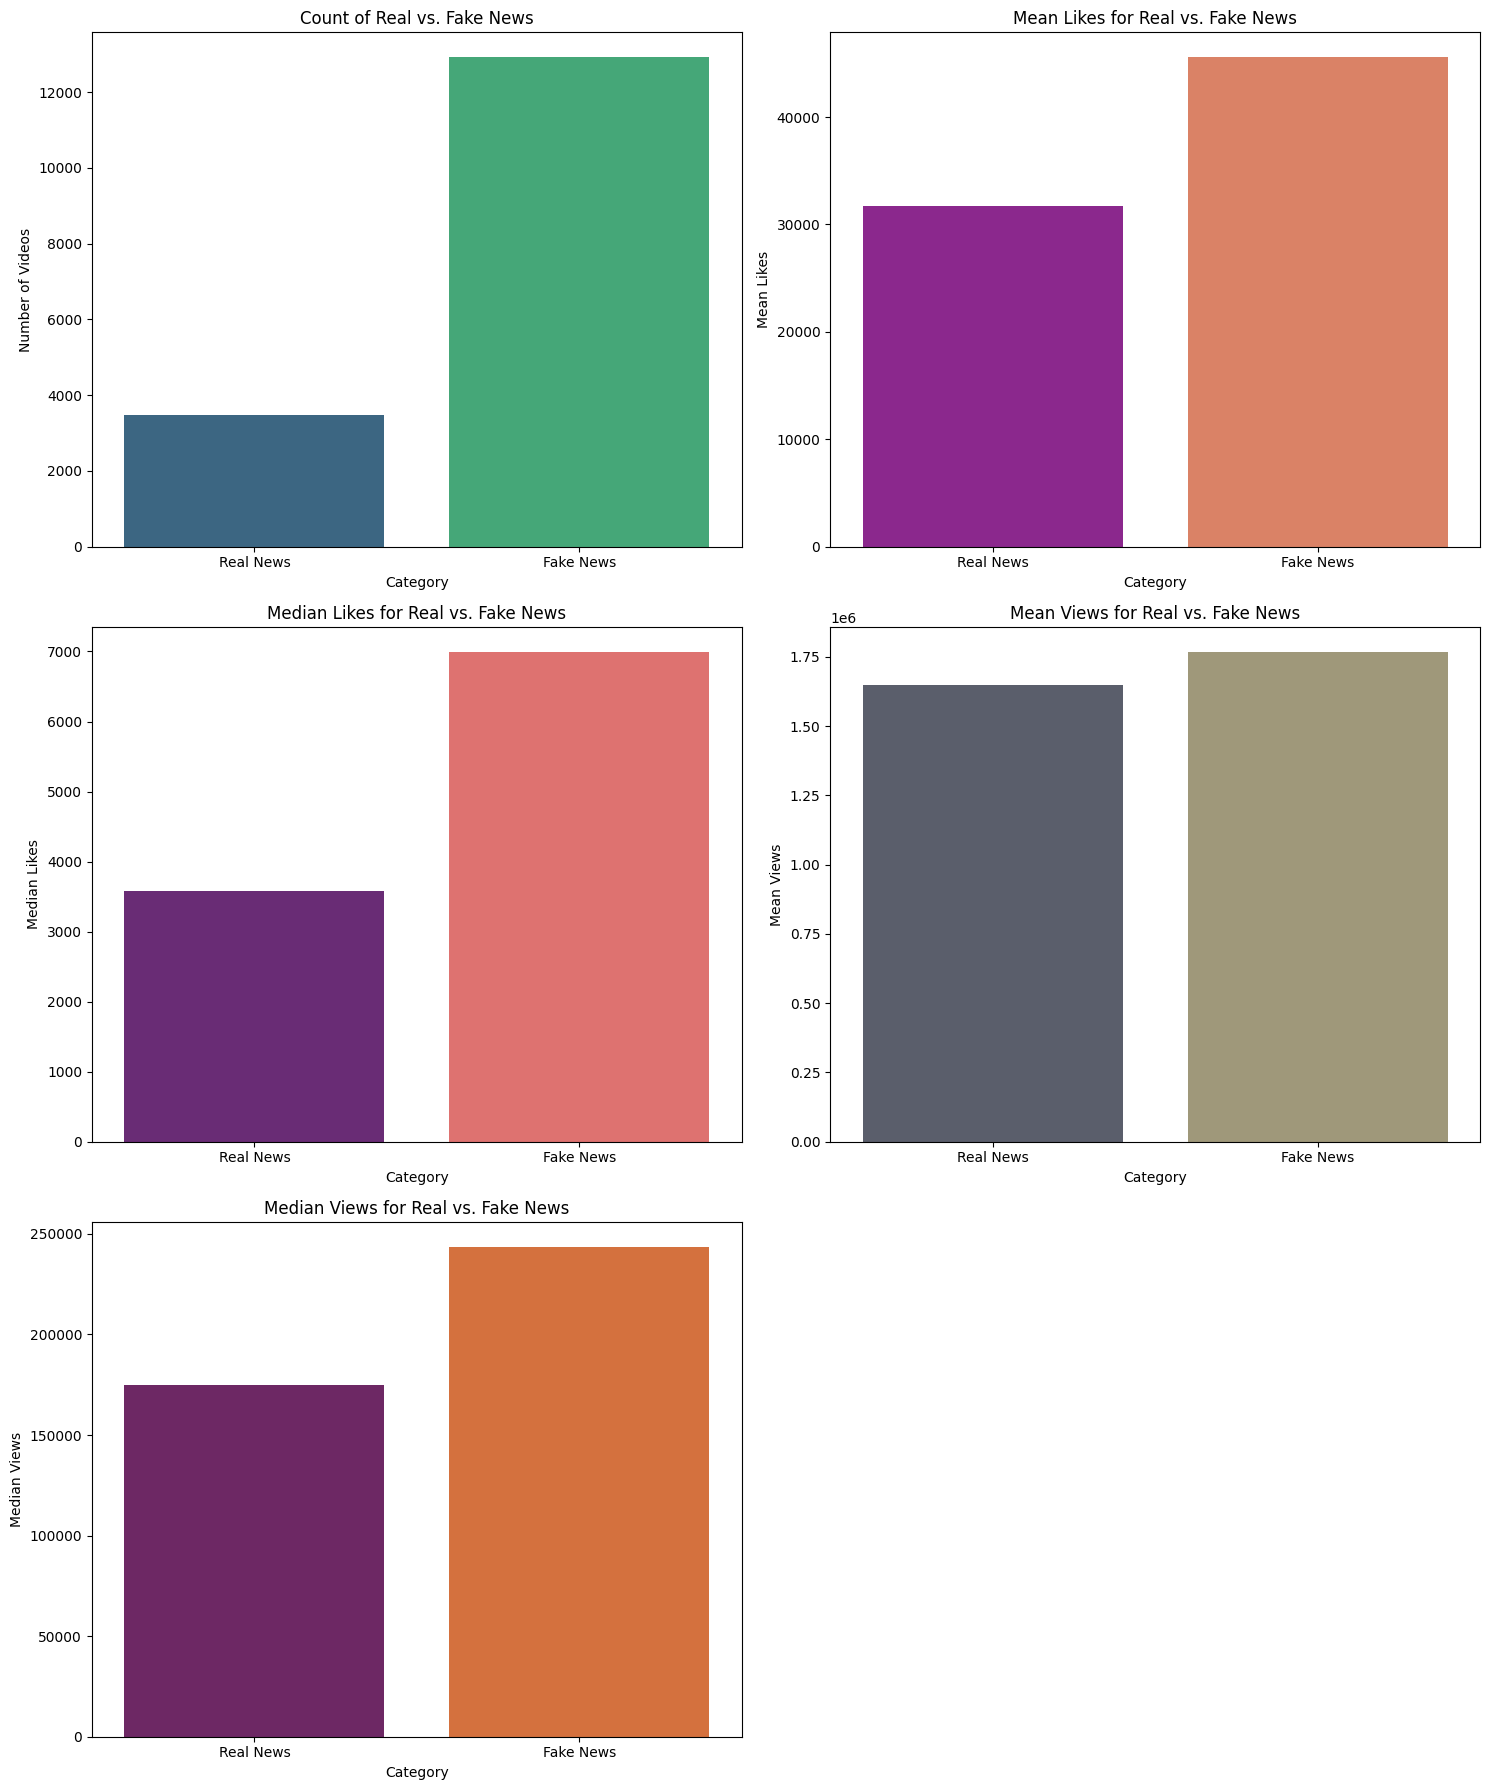

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
summary_data = {
    'Category': ['Real News', 'Fake News'],
    'Count': [len(real_news_df), len(fake_news_df)],
    'Mean Likes': [real_news_df['likes'].mean(), fake_news_df['likes'].mean()],
    'Median Likes': [real_news_df['likes'].median(), fake_news_df['likes'].median()],
    'Mean Views': [real_news_df['views'].mean(), fake_news_df['views'].mean()],
    'Median Views': [real_news_df['views'].median(), fake_news_df['views'].median()]
}
summary_df = pd.DataFrame(summary_data)

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

# Plot Count
sns.barplot(x='Category', y='Count', data=summary_df, ax=axes[0], palette='viridis', legend=False, hue='Category')
axes[0].set_title('Count of Real vs. Fake News')
axes[0].set_ylabel('Number of Videos')

# Plot Mean Likes
sns.barplot(x='Category', y='Mean Likes', data=summary_df, ax=axes[1], palette='plasma', legend=False, hue='Category')
axes[1].set_title('Mean Likes for Real vs. Fake News')
axes[1].set_ylabel('Mean Likes')

# Plot Median Likes
sns.barplot(x='Category', y='Median Likes', data=summary_df, ax=axes[2], palette='magma', legend=False, hue='Category')
axes[2].set_title('Median Likes for Real vs. Fake News')
axes[2].set_ylabel('Median Likes')

# Plot Mean Views
sns.barplot(x='Category', y='Mean Views', data=summary_df, ax=axes[3], palette='cividis', legend=False, hue='Category')
axes[3].set_title('Mean Views for Real vs. Fake News')
axes[3].set_ylabel('Mean Views')

# Plot Median Views
sns.barplot(x='Category', y='Median Views', data=summary_df, ax=axes[4], palette='inferno', legend=False, hue='Category')
axes[4].set_title('Median Views for Real vs. Fake News')
axes[4].set_ylabel('Median Views')

# Hide the last subplot if it's empty (in this case, axes[5])
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Below is a bar graph displaying common words used, removing small words as well as those out of the vocabulary. Not super interesting results, since the counts for fake news are likely higher due to them just having more data classified into it.

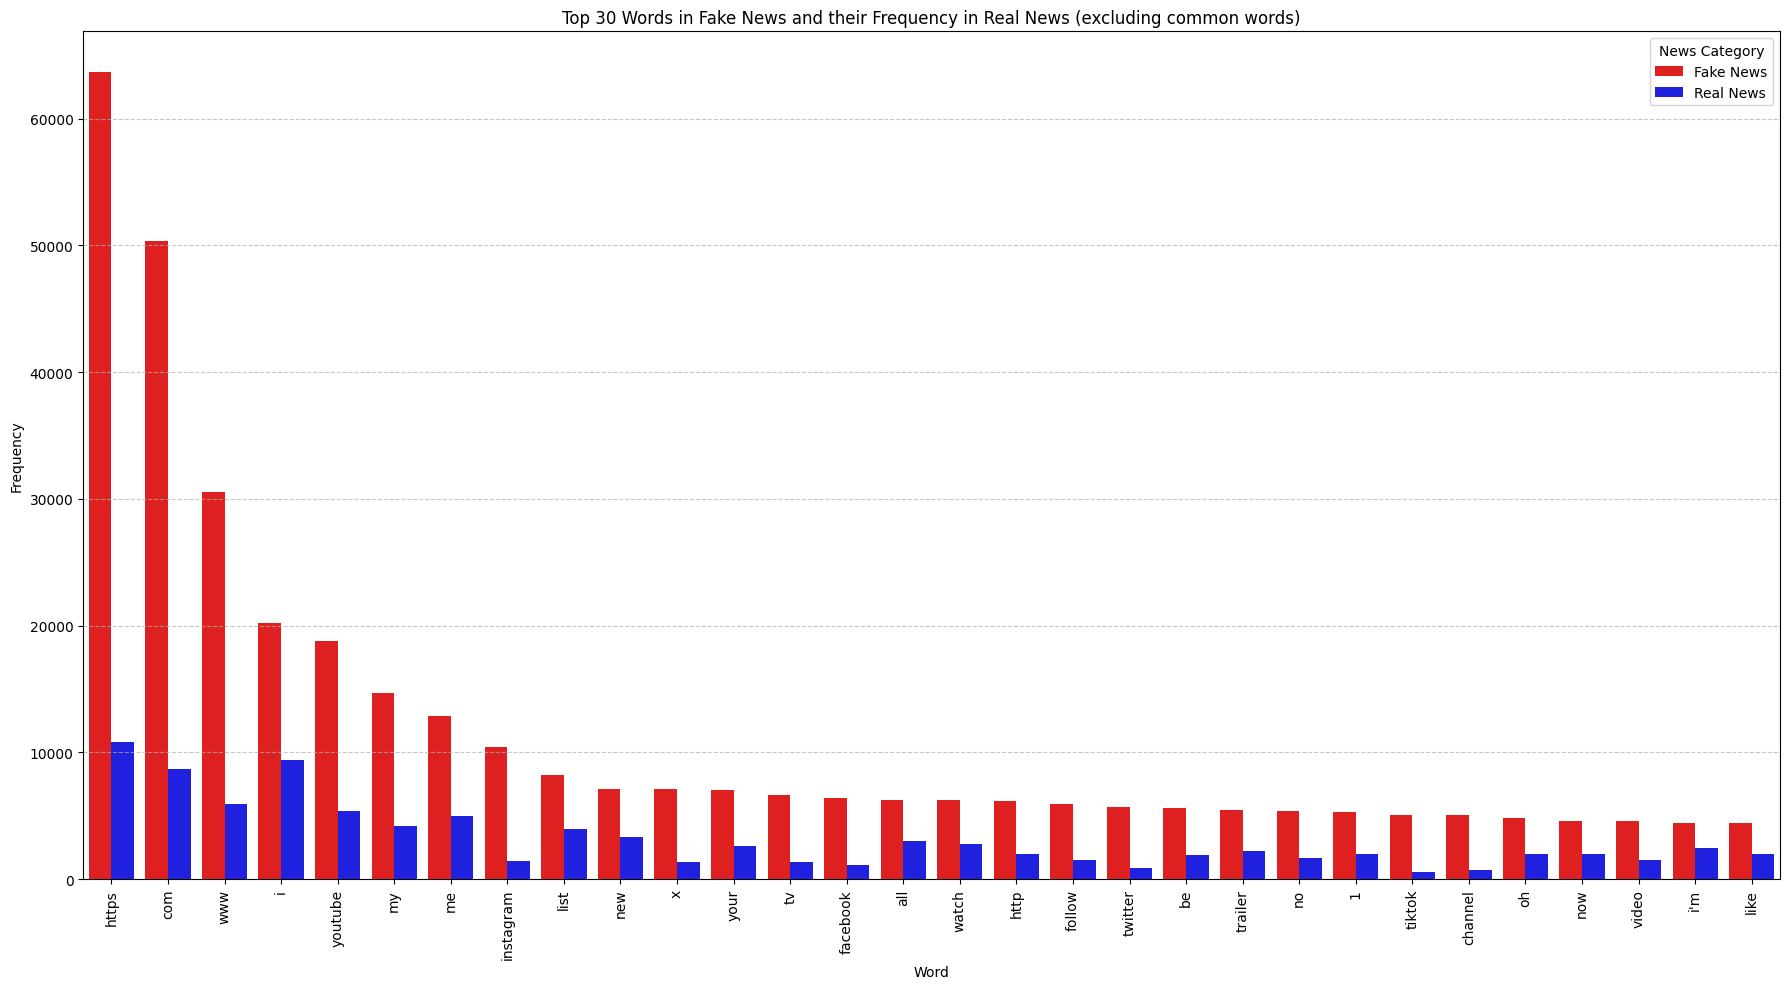

In [27]:
import collections

# Combine title and description for fake news and real news
# Fill NaN values in description with empty strings before concatenation
fake_news_text = fake_news_df['title'] + ' ' + fake_news_df['description'].fillna('')
real_news_text = real_news_df['title'] + ' ' + real_news_df['description'].fillna('')

# Tokenize the text for both categories
fake_news_tokens = loaded_tokenizer.texts_to_sequences(fake_news_text)
real_news_tokens = loaded_tokenizer.texts_to_sequences(real_news_text)

# Flatten the list of lists of tokens into single lists
flat_fake_tokens = [item for sublist in fake_news_tokens for item in sublist]
flat_real_tokens = [item for sublist in real_news_tokens for item in sublist]

# Create a reverse mapping from token ID to word
index_word = {v: k for k, v in loaded_tokenizer.word_index.items()}

# Define common words to remove, including the OOV token
stopwords_to_remove = ['<OOV>', 'is', 'you', 'a', 'the', 'and', 'to', 'in', 'of', 'for', 'it', 'with', 'on', 'from', 'as', 'but', 'or', 'at', 'by', 'an', 'this', 'that']

# Convert token IDs back to words, filtering out padding (token_id=0) and stopwords
fake_news_words = [index_word[token_id] for token_id in flat_fake_tokens if token_id != 0 and index_word.get(token_id) not in stopwords_to_remove]
real_news_words = [index_word[token_id] for token_id in flat_real_tokens if token_id != 0 and index_word.get(token_id) not in stopwords_to_remove]

# Count word frequencies for both categories
fake_news_word_counts = collections.Counter(fake_news_words)
real_news_word_counts = collections.Counter(real_news_words)

# Get the top N words from fake news
N = 30 # You can adjust this number
top_fake_words = fake_news_word_counts.most_common(N)

# Prepare data for plotting
plot_data = []
for word, fake_count in top_fake_words:
    real_count = real_news_word_counts.get(word, 0) # Get count from real news, 0 if not present
    plot_data.append({'Word': word, 'Category': 'Fake News', 'Count': fake_count})
    plot_data.append({'Word': word, 'Category': 'Real News', 'Count': real_count})

word_distribution_df = pd.DataFrame(plot_data)

# Create the bar graph
plt.figure(figsize=(18, 10))
sns.barplot(x='Word', y='Count', hue='Category', data=word_distribution_df,
            palette={'Fake News': 'red', 'Real News': 'blue'})
plt.title(f'Top {N} Words in Fake News and their Frequency in Real News (excluding common words)')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=90) # Rotate x-axis labels for readability
plt.legend(title='News Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()